# Homework 6: Linear Regression Modleing and Diagnostics
Build a predictive model for life expectancy using scikit-learn and perform a diagnostic audit to ensure the model’s coefficients are stable and mathematically sound.

## Task 1: Baseline Modeling
Load the WHO Life Expectancy Dataset, remove non-numeric columns (Country, Year), Convert Status column to  numeric, handle missing values.
- Use StandardScaler from sklearn.preprocessing to scale all independent variables. ("Life expectancy" is dependent variable) 
- Train a LinearRegression model using the scaled features.
- Report the R-Squared Score.
- Coefficient Analysis: Rank the features by their absolute coefficient values. Because the data is scaled, the largest coefficient now represents the most important predictor.

## Task 2: Iterative Diagnostic (VIF < 5)
Before analyzing the data, you must understand the Variance Inflation Factor (VIF) diagnostic. VIF measures multicollinearity, the degree to which your predictors are redundant.
High multicollinearity inflates the variance of coefficients, making them unreliable and difficult to interpret.
VIF is calculated by regressing one predictor against all others, then you obtain R_Squared and then compute VIF = 1/(1-R_Squared)
You sohuld use a cutoff of 5. Any variable with a VIF > 5 is considered too redundant and will be removed to improve the model's structural integrity. To do that follow the instruction below:

### Write a loop to iteratively remove the most redundant feature:
    1. Calculate VIF for every feature in the scaled dataset.
    2. Find the variable with the highest VIF.
    3. If VIF > 5, remove that feature from the data.
    4. Repeats the process until all remaining features have a VIF < 5
    - Note that in each iteration you remove only the highest VIF if it is greatet than 5!
    
## Task 3: Comparison of Model Results
    - Train a new LinearRegression model using only the independent features that survived the VIF diagnostic test.
    - Report the R-Squared Score.
    - Coefficient Analysis: Rank the features by their absolute coefficient values. Because the data is scaled, the largest coefficient now represents the most important predictor.
    - Are the top 5 predicotrs remain the same as those of the Baseline Model?

## Task 4: Residual Analysis and Normality
A good regression model should have errors (residuals) that are normally distributed and centered around zero.

    - Generate a histogram of the residuals for your baseline and clean model side by side.
    - Does the error distributions look like a bell curve?

## Task 5: The Interaction Investigation
In the real world application, the effect of one variable often depends on another. This is called an interaction.

    - Select two variables of your choice from the dataset (only variables with VIF >5) that you believe might have a combined effect (e.g., Alcohol and GDP, or BMI and HIV/AIDS,). Write one sentence explaining why you think they interact.
    - Create a new column in your dataframe by multiplying these two variables together.
    - Train a new model by adding this new interaction term to your dataset and fit it again using LinearRegression.
    - Report the R-Squared Score.
    - Is the interaction coeficient positive or negative? Has adding it improved the Model performance?




# Task 1

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [4]:
# Load data
df = pd.read_csv("Life_Expectancy_Data.csv")
df.columns = df.columns.str.strip()
df["Status_Encoded"] = df["Status"].map({"Developed": 1, "Developing": 0})

# Drop non-numeric / unnecessary columns
df = df.drop(columns=["Country", "Year", "Status"])
df = df.dropna()


X = df.drop(columns=["Life expectancy"])
y = df["Life expectancy"]

In [5]:
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = baseline_model.predict(X_test)
baseline_r2 = r2_score(y_test, y_pred)

print("Baseline R^2:", round(baseline_r2, 4))

Baseline R^2: 0.8105


In [6]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": baseline_model.coef_,
    "Abs_Coefficient": np.abs(baseline_model.coef_)
})

coef_df = coef_df.sort_values(by="Abs_Coefficient", ascending=False)

print(coef_df)

                            Feature  Coefficient  Abs_Coefficient
7                 under-five deaths   -11.892135        11.892135
1                     infant deaths    11.676781        11.676781
17                        Schooling     2.652725         2.652725
11                         HIV/AIDS    -2.602024         2.602024
0                   Adult Mortality    -2.068296         2.068296
16  Income composition of resources     1.625756         1.625756
3            percentage expenditure     0.707995         0.707995
6                               BMI     0.538715         0.538715
2                           Alcohol    -0.455825         0.455825
18                   Status_Encoded     0.350829         0.350829
10                       Diphtheria     0.320418         0.320418
4                       Hepatitis B    -0.226244         0.226244
9                 Total expenditure     0.210803         0.210803
8                             Polio     0.210759         0.210759
14        

The baseline multiple linear regression model achieved an R² of 0.8105, indicating that approximately 81% of the variation in life expectancy is explained by the predictors.

Based on the standardized coefficients, the most influential variables include under-five deaths, infant deaths, schooling, HIV/AIDS prevalence, and adult mortality. Under-five deaths had the strongest negative association with life expectancy, while schooling and income composition showed positive relationships.

Some coefficients, such as infant deaths, display unexpected signs, which likely indicates the presence of multicollinearity among predictors. This suggests that certain variables may be capturing overlapping information, which will be addressed in the next step using VIF analysis.

# Task 2

In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [9]:
def calculate_vif(X_df):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X_df.columns
    vif_data["VIF"] = [
        variance_inflation_factor(X_df.values, i)
        for i in range(X_df.shape[1])
    ]
    return vif_data

In [11]:
# Start with scaled data as a DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

remaining_features = X_scaled_df.columns.tolist()

while True:
    vif_df = calculate_vif(X_scaled_df[remaining_features])
    max_vif = vif_df["VIF"].max()
    
    if max_vif <= 5:
        break
    
    feature_to_remove = vif_df.sort_values(by="VIF", ascending=False).iloc[0]["Feature"]
    print("Removing:", feature_to_remove, "with VIF =", round(max_vif, 2))
    
    remaining_features.remove(feature_to_remove)

final_vif_df = calculate_vif(X_scaled_df[remaining_features])

print("\nRemaining features:")
print(remaining_features)

print("\nFinal VIF table:")
print(final_vif_df.sort_values(by="VIF", ascending=False))

Removing: infant deaths with VIF = 212.19
Removing: GDP with VIF = 13.57
Removing: thinness  1-19 years with VIF = 7.6

Remaining features:
['Adult Mortality', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'Population', 'thinness 5-9 years', 'Income composition of resources', 'Schooling', 'Status_Encoded']

Final VIF table:
                            Feature       VIF
14                        Schooling  3.485792
13  Income composition of resources  2.934928
6                 under-five deaths  2.692277
1                           Alcohol  2.213318
9                        Diphtheria  2.070829
12               thinness 5-9 years  1.953136
11                       Population  1.827125
15                   Status_Encoded  1.823448
5                               BMI  1.788327
0                   Adult Mortality  1.784269
7                             Polio  1.700815
3                    

I calculated the Variance Inflation Factor (VIF) for each predictor to detect multicollinearity. I iteratively removed variables with VIF values greater than 5 until all remaining predictors had acceptable VIF values below 5.

# Task 3

In [13]:
# Use only the features that survived the VIF test
X_clean = X_scaled_df[remaining_features]


X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y, test_size=0.2, random_state=42
)


clean_model = LinearRegression()
clean_model.fit(X_train_clean, y_train_clean)


y_pred_clean = clean_model.predict(X_test_clean)


clean_r2 = r2_score(y_test_clean, y_pred_clean)
print("Clean Model R^2:", round(clean_r2, 4))

Clean Model R^2: 0.8058


In [14]:
clean_coef_df = pd.DataFrame({
    "Feature": remaining_features,
    "Coefficient": clean_model.coef_,
    "Abs_Coefficient": np.abs(clean_model.coef_)
})

clean_coef_df = clean_coef_df.sort_values(by="Abs_Coefficient", ascending=False)

print(clean_coef_df)

                            Feature  Coefficient  Abs_Coefficient
14                        Schooling     2.744360         2.744360
10                         HIV/AIDS    -2.617885         2.617885
0                   Adult Mortality    -2.181967         2.181967
13  Income composition of resources     1.732902         1.732902
1                           Alcohol    -0.670894         0.670894
2            percentage expenditure     0.668603         0.668603
5                               BMI     0.598661         0.598661
9                        Diphtheria     0.464776         0.464776
6                 under-five deaths    -0.446510         0.446510
15                   Status_Encoded     0.361663         0.361663
12               thinness 5-9 years    -0.264147         0.264147
3                       Hepatitis B    -0.259107         0.259107
7                             Polio     0.236767         0.236767
11                       Population     0.193608         0.193608
8         

In [15]:
baseline_top5 = coef_df["Feature"].head(5).tolist()
clean_top5 = clean_coef_df["Feature"].head(5).tolist()

print("Baseline Top 5:", baseline_top5)
print("Clean Model Top 5:", clean_top5)

Baseline Top 5: ['under-five deaths', 'infant deaths', 'Schooling', 'HIV/AIDS', 'Adult Mortality']
Clean Model Top 5: ['Schooling', 'HIV/AIDS', 'Adult Mortality', 'Income composition of resources', 'Alcohol']


I trained a second linear regression model using only the predictors that remained after the VIF diagnostic. The cleaned model achieved an R² of 0.8058, compared to 0.8105 in the baseline model. This indicates a slight decrease in predictive performance.

Comparing the top five predictors, the baseline model was dominated by highly correlated variables such as infant deaths and under-five deaths. After, the most important predictors shifted to schooling, HIV/AIDS prevalence, adult mortality, and income composition of resources.


# Task 4

In [16]:
# Baseline residuals
baseline_residuals = y_test - y_pred

# Clean model residuals
clean_residuals = y_test_clean - y_pred_clean

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns


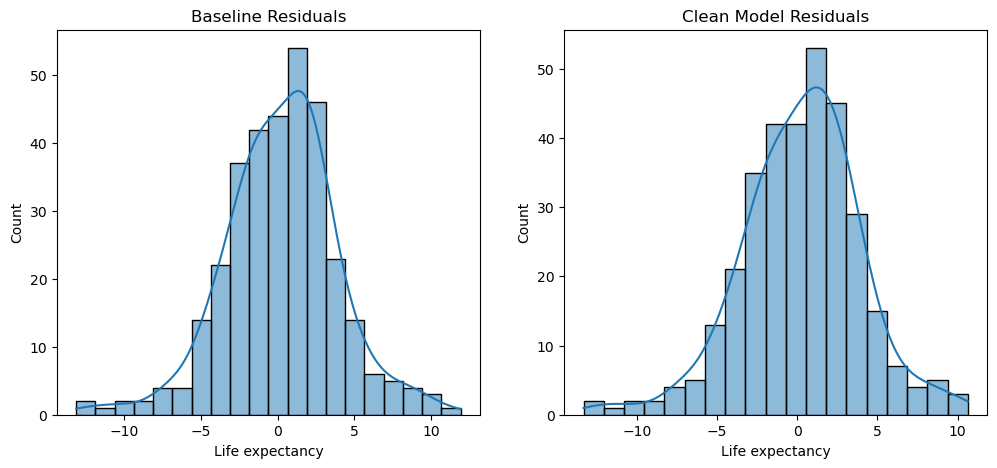

In [19]:
plt.figure(figsize=(12,5))


plt.subplot(1, 2, 1)
sns.histplot(baseline_residuals, kde=True)
plt.title("Baseline Residuals")


plt.subplot(1, 2, 2)
sns.histplot(clean_residuals, kde=True)
plt.title("Clean Model Residuals")

plt.show()

In both cases, the residuals appear to be approximately normally distributed and centered around zero, which is consistent with the assumptions of linear regression.

The clean model shows a slightly more symmetric and well-shaped bell curve compared to the baseline model, suggesting that reducing multicollinearity improved the overall structure of the model.

# Task 5

In [24]:
# HIV/AIDS and adult mortality interact because HIV/AIDS directly drives adult deaths;
# their combined effect on life expectancy is likely stronger than either alone.
df["hiv_mortality_interaction"] = df["HIV/AIDS"] * df["Adult Mortality"]

In [25]:
X_interaction = df.drop(columns=["Life expectancy"])

scaler_int = StandardScaler()
X_interaction_scaled = scaler_int.fit_transform(X_interaction)
X_interaction_df = pd.DataFrame(X_interaction_scaled, columns=X_interaction.columns)

X_train_int, X_test_int, y_train_int, y_test_int = train_test_split(
    X_interaction_df, y, test_size=0.2, random_state=42
)

interaction_model = LinearRegression()
interaction_model.fit(X_train_int, y_train_int)

y_pred_int = interaction_model.predict(X_test_int)
interaction_r2 = r2_score(y_test_int, y_pred_int)

print("Interaction Model R²:", round(interaction_r2, 4))

Interaction Model R²: 0.8271


In [26]:
interaction_coef = interaction_model.coef_[
    X_interaction_df.columns.get_loc("hiv_mortality_interaction")]

print("Interaction Coefficient:", round(interaction_coef, 4))

Interaction Coefficient: 1.8945


I selected HIV/AIDS and adult mortality as my interaction variables because HIV/AIDS is a major factor contributing to adult mortality, and their combined effect may influence life expectancy.

I created a new interaction term by multiplying these two variables and included it in a new regression model. The model achieved an R² of 0.8271, which is higher than the baseline model (0.8105), indicating an improvement in predictive performance.

The interaction coefficient was positive (1.8945), suggesting that the combined effect of these variables increases life expectancy. This result is likely influenced by the strong relationship between the variables, which can produce unexpected coefficient signs.
It showed that considering how these variables work together helps explain life expectancy more clearly.